In [1]:
import pandas as pd
from rdkit import Chem
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [42]:
df = pd.read_csv('../data/zinc_250.csv')
df.head()

,smiles,logP,qed,SAS
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1,5.05060,0.702012,2.084095
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1,3.11370,0.928975,3.432004
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182


Data preprocessing

In [43]:
df.shape

(249455, 4)

In [36]:
df.isnull().sum()

smiles    0
logP      0
qed       0
SAS       0
dtype: int64

In [37]:
df['smiles'] = df['smiles'].str.replace('\n', '').str.strip()

In [9]:
def validate_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

df['valid_smiles'] = df['smiles'].apply(validate_smiles)

invalid_rows = df[~df['valid_smiles']]
print(f"Некорректных SMILES: {len(invalid_rows)}")
print(invalid_rows[['smiles']])

Некорректных SMILES: 0
Empty DataFrame
Columns: [smiles]
Index: []


EDA

In [5]:
PALETTE = [
    "#F4A261",  
    "#E9C46A",  
    "#F6BD8D",  
    "#F7D5B1",  
    "#E76F51", 
    "#FDF0E0"   
]

sns.set_theme(style="whitegrid")
sns.set_palette(PALETTE)

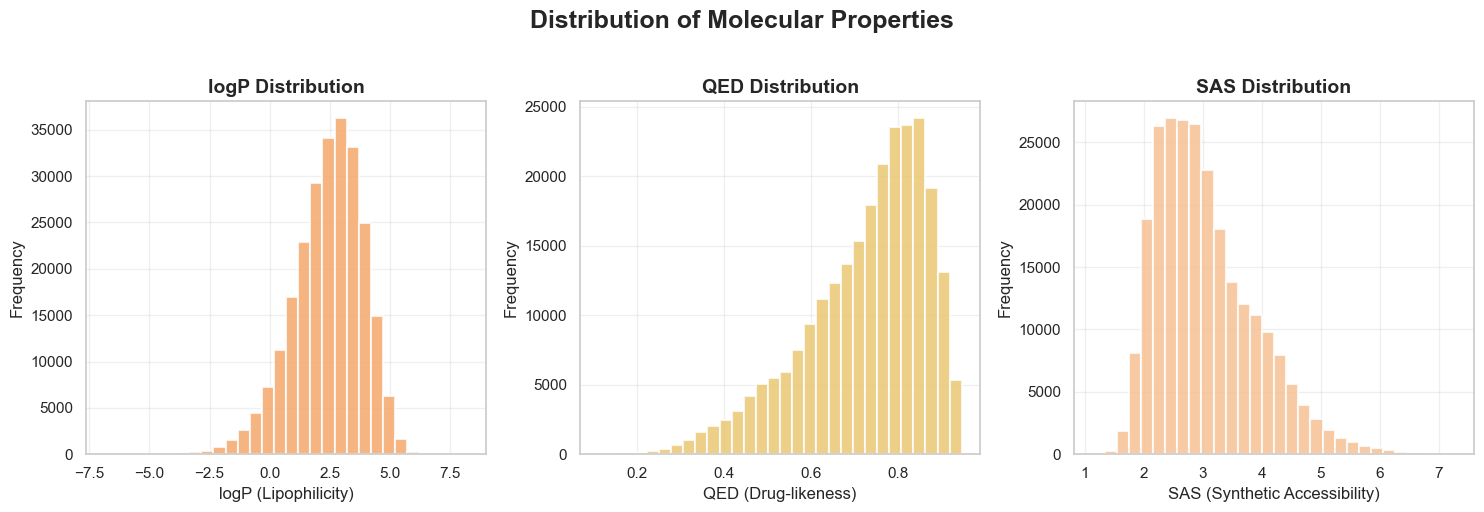

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribution of Molecular Properties', fontsize=18, fontweight='bold', y=1.02)

axes[0].hist(df['logP'], bins=30, color=PALETTE[0], edgecolor='white', alpha=0.8, linewidth=1.5)
axes[0].set_xlabel('logP (Lipophilicity)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('logP Distribution', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['qed'], bins=30, color=PALETTE[1], edgecolor='white', alpha=0.8, linewidth=1.5)
axes[1].set_xlabel('QED (Drug-likeness)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('QED Distribution', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].hist(df['SAS'], bins=30, color=PALETTE[2], edgecolor='white', alpha=0.8, linewidth=1.5)
axes[2].set_xlabel('SAS (Synthetic Accessibility)', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].set_title('SAS Distribution', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

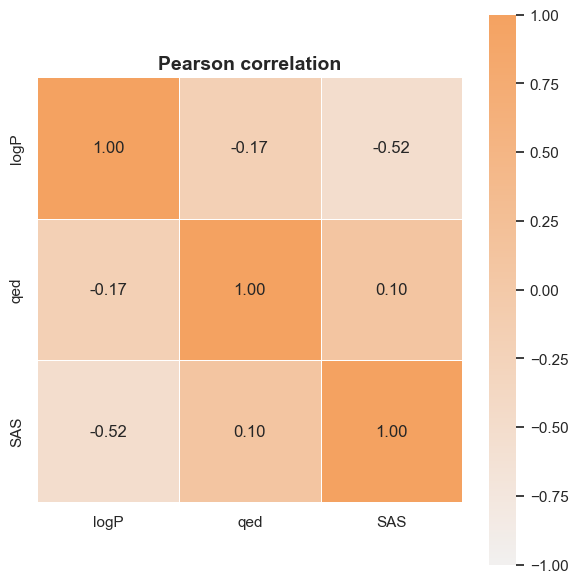

In [21]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

from evaluation.visualization import plot_pearson_correlation_heatmap

cols = ['logP', 'qed', 'SAS']
corr = df[cols].corr(method='pearson')

fig = plot_pearson_correlation_heatmap(corr)
plt.show()


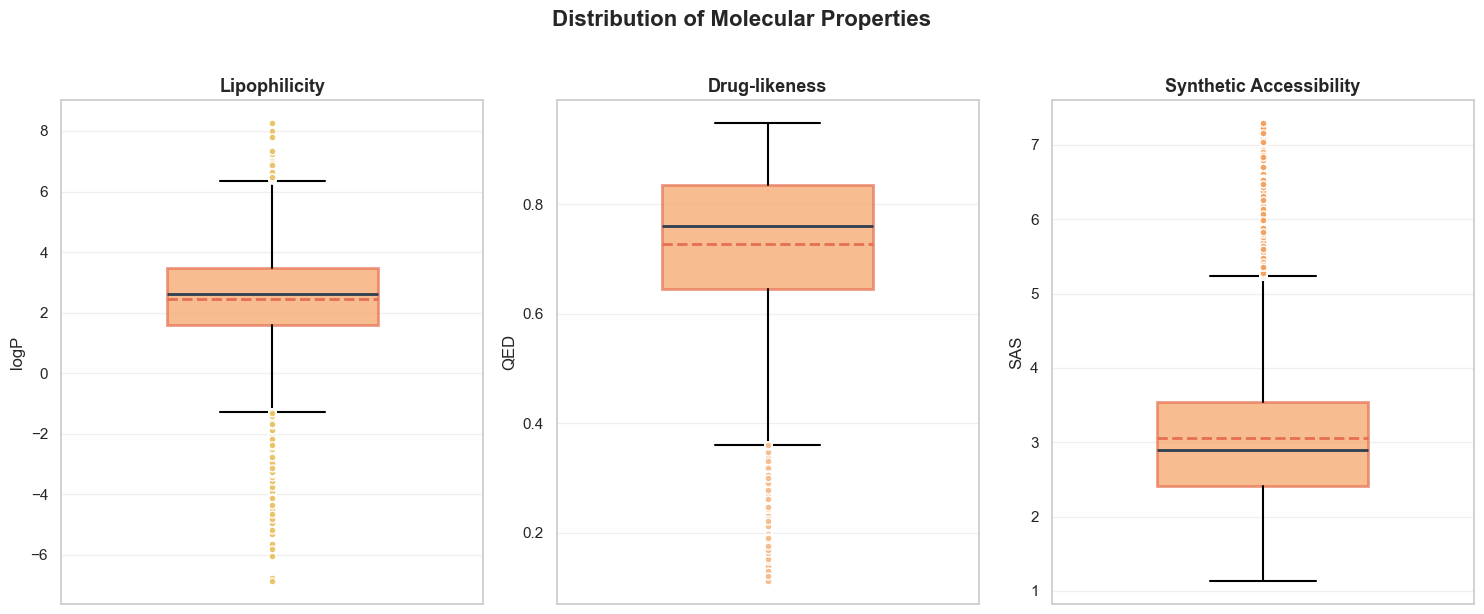

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Distribution of Molecular Properties', fontsize=16, fontweight='bold', y=1.02)

properties = [
    {'name': 'logP', 'data': df['logP'], 'color': PALETTE[1], 'ylabel': 'logP', 'title': 'Lipophilicity'},
    {'name': 'QED', 'data': df['qed'], 'color': PALETTE[2], 'ylabel': 'QED', 'title': 'Drug-likeness'},
    {'name': 'SAS', 'data': df['SAS'], 'color': PALETTE[0], 'ylabel': 'SAS', 'title': 'Synthetic Accessibility'}
]

for i, prop in enumerate(properties):
    bp = axes[i].boxplot( prop['data'], 
                         patch_artist=True,
                         widths=0.5,
                         showmeans=True,
                         meanline=True,
                         meanprops={'linestyle': '--', 'color': PALETTE[4], 'linewidth': 2},
                         medianprops={'linewidth': 2, 'color': '#2C3E50'},
                         whiskerprops={'linewidth': 1.5},
                         capprops={'linewidth': 1.5},
                         flierprops={'marker': 'o', 'markerfacecolor': prop['color'], 
                                    'markeredgecolor': 'white', 'markersize': 5})
    
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][0].set_edgecolor(PALETTE[4])
    bp['boxes'][0].set_linewidth(2)
    
    axes[i].set_ylabel(prop['ylabel'], fontsize=12)
    axes[i].set_title(prop['title'], fontsize=13, fontweight='bold')
    axes[i].set_xticks([])
    axes[i].grid(True, alpha=0.3, axis='y')
    

plt.tight_layout()
plt.show()